# 정책 반복법(Policy Iteration) 구현: 3x4 그리드 월드 예제

### GridWorld 시각화를 위한 설정

In [ ]:
import os
import urllib.request

if not os.path.exists("gridworld_render.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/common/gridworld_render.py"
    filename = "gridworld_render.py"
    urllib.request.urlretrieve(url, filename)

In [ ]:
import numpy as np
import gridworld_render as render_helper

### GridWorld 클래스의 정의

In [ ]:
class GridWorld:
    def __init__(self):
        self.action_space = [0, 1, 2, 3]  # 행동 공간(가능한 행동들)
        self.action_meaning = {  # 행동의 의미
            0: "UP",
            1: "DOWN",
            2: "LEFT",
            3: "RIGHT",
        }

        self.reward_map = np.array(  # 보상 맵(각 좌표의 보상 값)
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)    # 목표 상태(좌표)
        self.wall_state = (1, 1)    # 벽 상태(좌표)
        self.start_state = (2, 0)   # 시작 상태(좌표)
        self.agent_state = self.start_state   # 에이전트 초기 상태(좌표)

    @property
    def height(self):
        return len(self.reward_map)

    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h, w)

    def next_state(self, state, action):
        # 이동 위치 계산
        action_move_map = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        # 이동한 위치가 그리드 월드의 테두리 밖이나 벽인가?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state  # 다음 상태 반환

    def reward(self, state, action, next_state):
        return self.reward_map[next_state]

    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state

    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action)
        reward = self.reward(state, action, next_state)
        done = (next_state == self.goal_state)

        self.agent_state = next_state
        return next_state, reward, done

    def render_v(self, v=None, policy=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)


In [ ]:
env = GridWorld()

# env.height() 대신 env.height 로 사용 가능
print(env.height)  # [출력 결과] 3
print(env.width)   # [출력 결과] 4
print(env.shape)   # [출력 결과] (3, 4)

# 행동 공간(가능한 행동들)
for action in env.actions():
    print(action)

print('===')

# 상태 공간(가능한 상태들)
for state in env.states():
    print(state)

3
4
(3, 4)
0
1
2
3
===
(0, 0)
(0, 1)
(0, 2)
(0, 3)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(2, 0)
(2, 1)
(2, 2)
(2, 3)


### 예제) 더미 상태 가치 함수(random)를 기반으로 그리드 월드 시각화
(단, 목표지점인 (0,3)에서의 가치는 0)

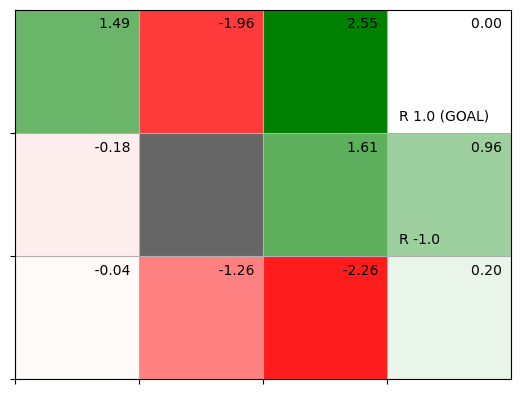

In [ ]:
V = {}
for state in env.states():
    V[state] = np.random.randn()

    if state == (0,3):
        V[state] = 0
    
env.render_v(V)

### defaultdict 으로 상태 가치 함수 초기화

In [ ]:
from collections import defaultdict  # defaultdict 클래스 임포트

V = defaultdict(lambda: 0)  # 모든 상태의 가치를 0으로 초기화

# 특정 상태에서의 가치 확인 - 상태(1,2)에서의 가치를 출력
state = (1,2)
print(V[state])

0


In [ ]:
# 4방향 uniform random 정책 구현: 모든 행동의 확률이 0.25로 동일
pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})

# 특정 상태에서의 정책 확인 - 상태(0,1)에서의 행동 확률 분포를 출력 -> 당연히 모든 행동이 똑같이 0.25로 동일
state = (0,1)
print(pi[state])

{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}


## 반복적 정책 평가 알고리즘 구현

 - 업데이트(갱신)를 한 단계만 수행하는 함수 구현: eval_onestep()
 - 4개의 매개변수를 받음:  
    1) pi(defaultdict): 정책
    2) V(defaultdict): 가치 함수
    3) env(GridWorld): 환경
    4) gamma(float): 감쇠 인자/discount factor

<img src="https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/image/state_approach_order.png">

In [ ]:
def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():  # 각 상태에 접근
        if state == env.goal_state:  # 목표 상태에서의 가치 함수는 항상 0
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0

        # 각 행동에 접근        
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            # 새로운 가치 함수
            new_V += action_prob * (r + gamma * V[next_state])

        V[state] = new_V
    return V

### 위의 eval_onestep() 함수로 가치 함수가 한 차례 업데이트(갱신)됨
### 이 갱신을 반복해야 함. 반복을 처리하는 함수 구현

In [ ]:
def policy_eval(pi, V, env, gamma, threshold=0.001):

    loop_count = 0

    while True:
        old_V = V.copy()  # 갱신 전 가치 함수
        V = eval_onestep(pi, V, env, gamma)
        loop_count += loop_count+1

        # 갱신된 양의 최댓값 계산
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 임계값과 비교
        if delta < threshold:
            print("eval_onestep 가치 반복 횟수: ", loop_count)
            break
    return V

### argmax() 함수의 구현: 딕셔너리를 매개변수로 받아 값이 가장 큰 원소의 키를 반환

In [ ]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key

### greedy_policy() 함수의 구현: 가치 함수 V, 환경 env, 감쇠인자 gamma 를 매개변수로 받고, 탐욕화한 정책(Greedy Policy)를 반환

In [ ]:
def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi

### 정책 반복법을 policy_iter 라는 함수로 구현

In [ ]:
def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)  # 평가
        new_pi = greedy_policy(V, env, gamma)          # 개선

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:  # 갱신 여부 확인
            break
        pi = new_pi

    return pi

eval_onestep 가치 반복 횟수:  8388607


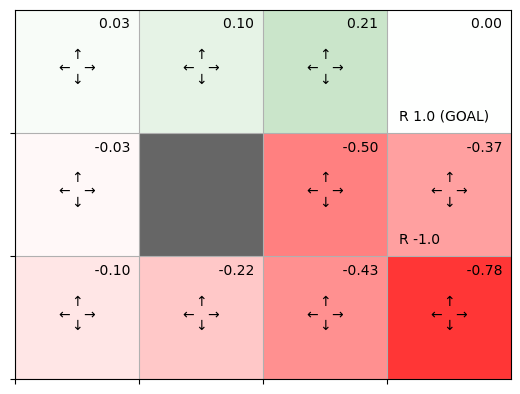

In [ ]:
env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma, threshold=0.001, is_render=True)

# 정책 출력
for state in env.states():
    print(f"State {state}: {pi[state]}")
# 정책의 가치 함수 출력
V = policy_eval(pi, defaultdict(lambda: 0), env, gamma)
env.render_v(V, pi, print_value=True)
